In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
import sys
import joblib


print("Load data")
df=pd.read_csv("breast_cancer_cov_180423.tsv",sep="\t")
df["family_hist_breast_cancer"]=[1 if "5" in str(row["Illness_mother"]).replace("[","").replace("]","").split(", ") else 0 for row in df.to_dict("records")]
df["Smoking_status"]=df["Smoking_status"].replace(-3,None)
df["Alcohol_freq"]=df["Alcohol_freq"].replace(-3,None)
df["Daily_alcohol_amount"]=df["Daily_alcohol_amount"].replace("-818",None)
df["Amount_of_alc_vs_10yrs_bef"]=df["Amount_of_alc_vs_10yrs_bef"].replace("-1",None).replace("-3",None)
df["Maternal_smoking_around_birth"]=df["Maternal_smoking_around_birth"].replace("-1",None).replace("-3",None)
df["Smokers_in_household"]=df["Smokers_in_household"].replace("-1",None).replace("-3",None)
df["Vigorous_exercise_p_week"]=df["Vigorous_exercise_p_week"].replace("-1",None).replace("-3",None)
df["Exercise_p_week"]=df["Exercise_p_week"].replace("-1",None).replace("-3",None)
df["Duration_of_moderate_activity"]=df["Duration_of_moderate_activity"].replace("-1",None).replace("-3",None)
df["Tea_intake"]=df["Tea_intake"].replace("-1",None).replace("-3",None).replace("-10",None)

for index,vitamin in enumerate(["Vitamin_A","Vitamin_B","Vitamin_C","Vitamin_D","Vitamin_E","Folate","Multivitamins_minerals"]):
    df[vitamin]=[1 if str(index+1) in str(row["Vitamin_supplements"]).replace("[","").replace("]","").split(", ") else 0 for row in df.to_dict("records")]



df=df[["IID","Age","Ever_smoked","Smoking_status","BMI","Vitamin_D","Alcohol_freq","family_hist_breast_cancer","Amount_of_alc_vs_10yrs_bef",
"Maternal_smoking_around_birth","Smokers_in_household","Vigorous_exercise_p_week","Exercise_p_week","Duration_of_moderate_activity","Tea_intake"]]

genotypes = pd.read_csv("extracted_genotypes_eminus3.raw", sep="\s+")

res_df=pd.merge(df,genotypes,on="IID",how="inner")


X=res_df.drop(columns=["IID","FID","PAT","MAT","SEX"])
#####################


 




#########################

X=X.fillna(X.mean())


 



scaler = MinMaxScaler()
scaler.fit(X[['Age', 'BMI','Vitamin_D','Alcohol_freq']])
X[['Age', 'BMI','Vitamin_D','Alcohol_freq']] = scaler.transform(X[['Age', 'BMI','Vitamin_D','Alcohol_freq']])

print("saving data")
from sklearn.utils import shuffle
X = shuffle(X)

y=[0 if ele==1 else 1 for ele in X["PHENOTYPE"]]
 


#############

X=X.drop('PHENOTYPE',axis=1)
 

#############


# Split the data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Train test splitted",flush=True)

 
 

Load data
saving data
Train test splitted


In [2]:
train=X


In [3]:
covs=train[train.columns[:14]]
covs

,Age,Ever_smoked,Smoking_status,BMI,Vitamin_D,Alcohol_freq,family_hist_breast_cancer,Amount_of_alc_vs_10yrs_bef,Maternal_smoking_around_birth,Smokers_in_household,Vigorous_exercise_p_week,Exercise_p_week,Duration_of_moderate_activity,Tea_intake
179635,0.25000,1.0,0.0,0.169216,0.0,0.4,0,2.000000,0.0,0.000000,0.0,-1.0,55.756278,5.0
43892,0.56250,1.0,2.0,0.372754,0.0,0.8,0,3.000000,0.0,0.114217,-1.0,-1.0,55.756278,4.0
241330,0.65625,1.0,2.0,0.445152,0.0,0.8,0,3.000000,0.0,0.000000,0.0,-1.0,55.756278,-10.0
139596,0.90625,1.0,1.0,0.410650,0.0,1.0,0,2.189829,0.0,0.000000,0.0,7.0,-1.000000,0.0
40011,0.56250,0.0,0.0,0.193645,0.0,0.4,0,3.000000,0.0,0.000000,5.0,7.0,90.000000,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172331,0.68750,1.0,2.0,0.186209,0.0,0.0,0,2.000000,1.0,0.114217,-1.0,-1.0,55.756278,0.0
178734,0.93750,1.0,0.0,0.231648,0.0,0.4,0,1.000000,0.0,0.000000,0.0,3.0,45.000000,4.0
167792,0.59375,1.0,1.0,0.149152,0.0,0.0,0,1.000000,0.0,0.000000,0.0,1.0,50.000000,4.0
178465,0.78125,0.0,0.0,0.299002,0.0,0.0,0,2.000000,0.0,0.000000,0.0,4.0,-1.000000,3.0


In [4]:
data=train[train.columns[14:]]
 
import numpy as np
data=np.round(data)
 


In [5]:
data

,rs6696971_T,rs115765087_A,rs116161617_A,rs2840536_G,rs12567869_A,rs1122723_G,rs10915421_C,rs579387_C,rs10915585_T,rs59390834_A,...,rs12158321_C,rs17779492_A,rs5771096_T,rs5771225_T,rs11553141_C,rs134975_T,rs75276302_A,rs131807_G,rs140522_T,rs2269380_G
179635,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
43892,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,1.0,0.0
241330,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0
139596,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
40011,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172331,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
178734,0.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,0.0,...,0.0,2.0,0.0,2.0,0.0,2.0,0.0,2.0,1.0,0.0
167792,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,2.0,1.0,1.0,0.0,1.0,1.0,1.0
178465,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,2.0,0.0,1.0,1.0,0.0


In [6]:
y=[0 if ele==1 else 1 for ele in y]
#y0=[0 if ele==1 else 1 for ele in y0]
 
 

In [7]:
def  kin_energy(random_vec):
    """return    kinetic  energy  of   random vector represented   of   (1,) dimmensional  array"""
    freq=np.unique(random_vec,return_counts=True)
    #prob=freq[1]/random_vec.shape[0]
    prob=freq[1]/len(random_vec)
    energy=np.sum(prob**2)
    return  energy
              
import numpy as np
a=np.array([1,3,2,2])
print(kin_energy(a))
#case with     total energy
a=np.array([1,1,1,1,1,1])
print(kin_energy(a))
#case  with    converging    to  zero
a=np.array([1,2,3,4,5,6,7,8,9,10])
print(kin_energy(a))

0.375
1.0
0.10000000000000003


In [8]:
data['kinetc']=data.apply(lambda x:kin_energy(x),axis=1)

/tmp/ipykernel_6148/1569205571.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['kinetc']=data.apply(lambda x:kin_energy(x),axis=1)


(array([  1653.,  76080., 155581.,  20091.,   3387.,   1427.,    973.,
          2679.,   2508.,    248.]),
 array([0.52426658, 0.53659554, 0.54892449, 0.56125345, 0.57358241,
        0.58591137, 0.59824032, 0.61056928, 0.62289824, 0.63522719,
        0.64755615]),
 <BarContainer object of 10 artists>)

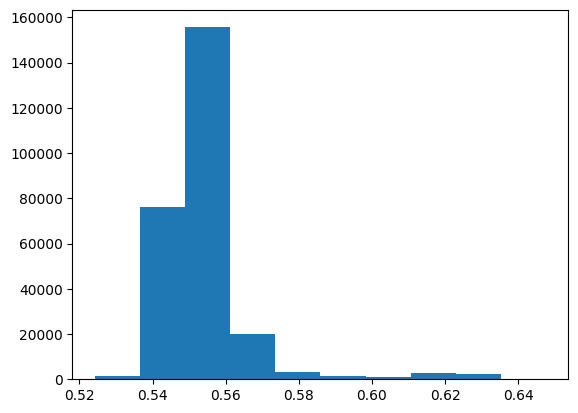

In [9]:
import matplotlib
from matplotlib import pyplot as plt
plt.hist(data['kinetc'])

In [10]:
l=data['kinetc']

In [11]:
n=data.shape[0]/4

In [12]:
def round_robin_sublists(l, n=4):
    lists = [[] for _ in range(n)]
    i = 0
    for elem in l:
        lists[i].append(elem)
        i = (i + 1) % n
    return lists

 
sublist = round_robin_sublists(l) # [[1, 5, 9], [2, 6, 10], [3, 7], [4, 8]]

In [13]:
len(sublist)

4

In [14]:
len(sublist[0])

66157

In [15]:
len(sublist[1])

66157

In [16]:
data['y']=y

/tmp/ipykernel_6148/1327028962.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['y']=y


In [17]:
interval1=data[data['kinetc'].isin(sublist[0])]

(array([  2161.,  92263., 129843.,  10098.,   1042.,    428.,    230.,
           733.,   1022.,    164.]),
 array([0.52728421, 0.5389454 , 0.5506066 , 0.5622678 , 0.57392899,
        0.58559019, 0.59725138, 0.60891258, 0.62057377, 0.63223497,
        0.64389617]),
 <BarContainer object of 10 artists>)

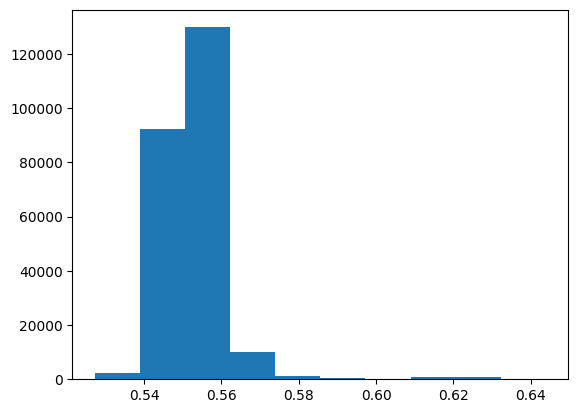

In [18]:
plt.hist(interval1['kinetc'])

In [19]:
y_i1=interval1['y']

In [20]:
interval1=interval1.drop('y',axis=1)

In [21]:
 # evaluating xgboost model with default parameters  on 10 cross validations with  5 metrics most importantt is:
#f1 score and proportions of predictions , balanced acc and  auc
import xgboost as xgb
from joblib import dump, load
acc_score=[]
balanced_acc=[]
f1=[]
distro=[]
auc=[]
 
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score
for cross_val in range(1):
    X_train, X_test, y_train, y_test = train_test_split(interval1, y_i1, test_size=0.33, random_state=np.random.randint(12345))
 
    
    #model_xgb=xgb.XGBClassifier(tree_method='gpu_hist',n_estimators=317,scale_pos_weight=8,max_depth=5)
    model_xgb=LogisticRegression(random_state=1234,max_iter=5000)
    
    model_xgb.fit(X_train,y_train)
   
    pred_xgb=model_xgb.predict(np.array(X_test))
    acc_score.append(accuracy_score(pred_xgb,y_test))
    balanced_acc.append(balanced_accuracy_score(pred_xgb,y_test))
    
    auc.append(roc_auc_score(y_test,model_xgb.predict_proba(X_test)[:,1]))
    f1.append(f1_score(pred_xgb,y_test))
    neg, pos = np.bincount(pred_xgb)
    total = neg + pos
    print('Examples:\n    Total: {}\n    Positive: {} ({:.2f}% of total)\n'.format(
        total, pos, 100 * pos / total))
    distro.append(100*pos/total)

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Examples:
    Total: 78535
    Positive: 77452 (98.62% of total)



In [22]:
auc

[0.7662651170130713]

In [23]:
f1

[0.9685469814609412]

In [25]:
np.unique(y_i1,return_counts=True)

(array([0, 1]), array([ 13604, 224380]))

In [26]:
np.unique(pred_xgb,return_counts=True)

(array([0, 1]), array([ 1083, 77452]))

In [27]:
interval2=data[data['kinetc'].isin(sublist[1])]

(array([  2015.,  90491., 131528.,  10259.,    998.,    416.,    235.,
           806.,    981.,    135.]),
 array([0.52690841, 0.53868817, 0.55046793, 0.56224769, 0.57402745,
        0.58580721, 0.59758697, 0.60936673, 0.62114649, 0.63292625,
        0.64470601]),
 <BarContainer object of 10 artists>)

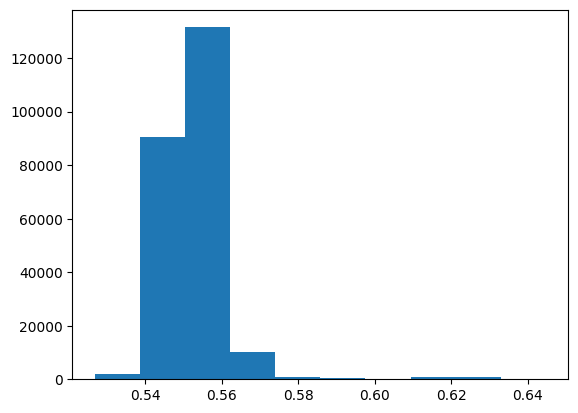

In [29]:
plt.hist(interval2['kinetc'])

In [30]:
y_i2=interval2['y']

In [31]:
interval2=interval2.drop('y',axis=1)

In [32]:
 # evaluating xgboost model with default parameters  on 10 cross validations with  5 metrics most importantt is:
#f1 score and proportions of predictions , balanced acc and  auc
import xgboost as xgb
from joblib import dump, load
acc_score=[]
balanced_acc=[]
f1=[]
distro=[]
auc=[]
 
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score
for cross_val in range(1):
    X_train, X_test, y_train, y_test = train_test_split(interval2, y_i2, test_size=0.33, random_state=np.random.randint(12345))
 
    
    #model_xgb=xgb.XGBClassifier(tree_method='gpu_hist',n_estimators=317,scale_pos_weight=8,max_depth=5)
    model_xgb=LogisticRegression(random_state=1234,max_iter=5000)
    
    model_xgb.fit(X_train,y_train)
   
    pred_xgb=model_xgb.predict(np.array(X_test))
    acc_score.append(accuracy_score(pred_xgb,y_test))
    balanced_acc.append(balanced_accuracy_score(pred_xgb,y_test))
    
    auc.append(roc_auc_score(y_test,model_xgb.predict_proba(X_test)[:,1]))
    f1.append(f1_score(pred_xgb,y_test))
    neg, pos = np.bincount(pred_xgb)
    total = neg + pos
    print('Examples:\n    Total: {}\n    Positive: {} ({:.2f}% of total)\n'.format(
        total, pos, 100 * pos / total))
    distro.append(100*pos/total)

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Examples:
    Total: 78496
    Positive: 77361 (98.55% of total)



In [33]:
auc 

[0.7643052626788234]

In [34]:
f1

[0.9685746574935068]

In [35]:
np.unique(pred_xgb,return_counts=True)

(array([0, 1]), array([ 1135, 77361]))

In [36]:
np.unique(y_i2,return_counts=True)

(array([0, 1]), array([ 13667, 224197]))

In [37]:
interval3=data[data['kinetc'].isin(sublist[2])]

(array([7.57000e+02, 7.11970e+04, 1.47639e+05, 1.43740e+04, 1.05500e+03,
        4.19000e+02, 2.46000e+02, 7.85000e+02, 9.50000e+02, 1.00000e+02]),
 array([0.52477575, 0.53693825, 0.54910076, 0.56126327, 0.57342577,
        0.58558828, 0.59775079, 0.60991329, 0.6220758 , 0.63423831,
        0.64640081]),
 <BarContainer object of 10 artists>)

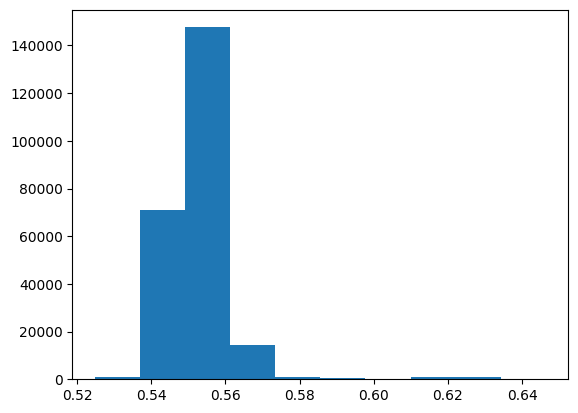

In [38]:
plt.hist(interval3['kinetc'])

In [39]:
y_i3=interval3['y']

In [40]:
interval3=interval3.drop('y',axis=1)

In [41]:
np.unique(y_i3,return_counts=True)

(array([0, 1]), array([ 13571, 223951]))

In [42]:
 # evaluating xgboost model with default parameters  on 10 cross validations with  5 metrics most importantt is:
#f1 score and proportions of predictions , balanced acc and  auc
import xgboost as xgb
from joblib import dump, load
acc_score=[]
balanced_acc=[]
f1=[]
distro=[]
auc=[]
 
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score
for cross_val in range(1):
    X_train, X_test, y_train, y_test = train_test_split(interval3, y_i3, test_size=0.33, random_state=np.random.randint(12345))
 
    
    #model_xgb=xgb.XGBClassifier(tree_method='gpu_hist',n_estimators=317,scale_pos_weight=8,max_depth=5)
    model_xgb=LogisticRegression(random_state=1234,max_iter=5000)
    
    model_xgb.fit(X_train,y_train)
   
    pred_xgb=model_xgb.predict(np.array(X_test))
    acc_score.append(accuracy_score(pred_xgb,y_test))
    balanced_acc.append(balanced_accuracy_score(pred_xgb,y_test))
    
    auc.append(roc_auc_score(y_test,model_xgb.predict_proba(X_test)[:,1]))
    f1.append(f1_score(pred_xgb,y_test))
    neg, pos = np.bincount(pred_xgb)
    total = neg + pos
    print('Examples:\n    Total: {}\n    Positive: {} ({:.2f}% of total)\n'.format(
        total, pos, 100 * pos / total))
    distro.append(100*pos/total)

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Examples:
    Total: 78383
    Positive: 77361 (98.70% of total)



In [43]:
auc

[0.7595154577480867]

In [44]:
f1

[0.9692290403823399]

In [45]:
np.unique(pred_xgb,return_counts=True)

(array([0, 1]), array([ 1022, 77361]))

In [46]:
balanced_acc

[0.6773529879523077]

In [47]:
acc_score

[0.9406121225265682]

In [48]:
interval4=data[data['kinetc'].isin(sublist[3])]

(array([5.50000e+02, 6.91560e+04, 1.50167e+05, 1.44400e+04, 1.09500e+03,
        4.07000e+02, 3.03000e+02, 8.63000e+02, 8.74000e+02, 6.00000e+01]),
 array([0.52426658, 0.53659554, 0.54892449, 0.56125345, 0.57358241,
        0.58591137, 0.59824032, 0.61056928, 0.62289824, 0.63522719,
        0.64755615]),
 <BarContainer object of 10 artists>)

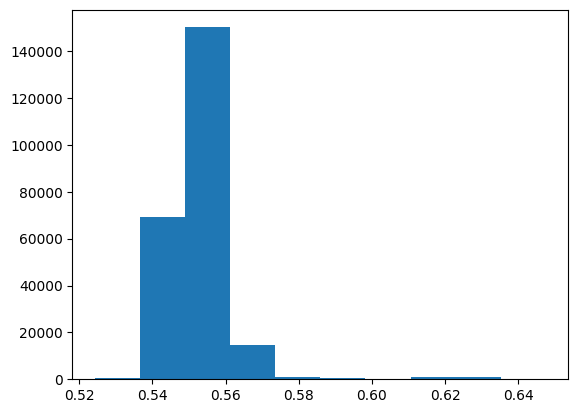

In [49]:
plt.hist(interval4['kinetc'])

(array([7.57000e+02, 7.11970e+04, 1.47639e+05, 1.43740e+04, 1.05500e+03,
        4.19000e+02, 2.46000e+02, 7.85000e+02, 9.50000e+02, 1.00000e+02]),
 array([0.52477575, 0.53693825, 0.54910076, 0.56126327, 0.57342577,
        0.58558828, 0.59775079, 0.60991329, 0.6220758 , 0.63423831,
        0.64640081]),
 <BarContainer object of 10 artists>)

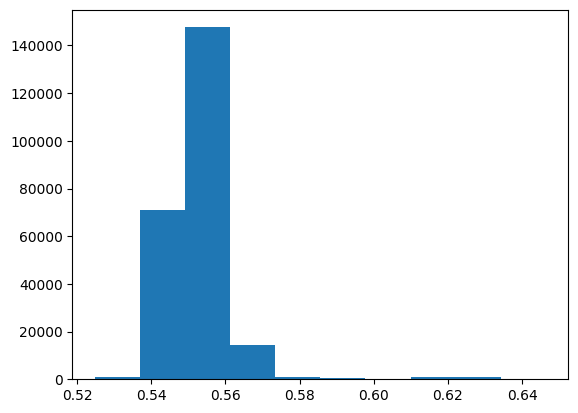

In [50]:
plt.hist(interval3['kinetc'])

In [51]:
y_i4=interval4['y']

In [52]:
interval4=interval4.drop('y',axis=1)

In [53]:
np.unique(y_i4,return_counts=True)

(array([0, 1]), array([ 13587, 224328]))

In [54]:
 # evaluating xgboost model with default parameters  on 10 cross validations with  5 metrics most importantt is:
#f1 score and proportions of predictions , balanced acc and  auc
import xgboost as xgb
from joblib import dump, load
acc_score=[]
balanced_acc=[]
f1=[]
distro=[]
auc=[]
 
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score
for cross_val in range(1):
    X_train, X_test, y_train, y_test = train_test_split(interval4, y_i4, test_size=0.33, random_state=np.random.randint(12345))
 
    
    #model_xgb=xgb.XGBClassifier(tree_method='gpu_hist',n_estimators=317,scale_pos_weight=8,max_depth=5)
    model_xgb=LogisticRegression(random_state=1234,max_iter=5000)
    
    model_xgb.fit(X_train,y_train)
   
    pred_xgb=model_xgb.predict(np.array(X_test))
    acc_score.append(accuracy_score(pred_xgb,y_test))
    balanced_acc.append(balanced_accuracy_score(pred_xgb,y_test))
    
    auc.append(roc_auc_score(y_test,model_xgb.predict_proba(X_test)[:,1]))
    f1.append(f1_score(pred_xgb,y_test))
    neg, pos = np.bincount(pred_xgb)
    total = neg + pos
    print('Examples:\n    Total: {}\n    Positive: {} ({:.2f}% of total)\n'.format(
        total, pos, 100 * pos / total))
    distro.append(100*pos/total)

In [ ]:
auc

In [ ]:
f1

In [ ]:
balanced_acc

In [ ]:
acc_score

In [ ]:
np.unique(pred_xgb,return_counts=True)